Ginger columns found:
['Ginger']

Using commodity: Ginger

TOP 5 COMMODITIES CO-MOVING WITH GINGER
     Commodity  Correlation with Ginger
     Tiger nut                    0.730
 Cassava dough                    0.575
    Garden egg                    0.537
Plantain riped                    0.517
  Banana local                    0.514


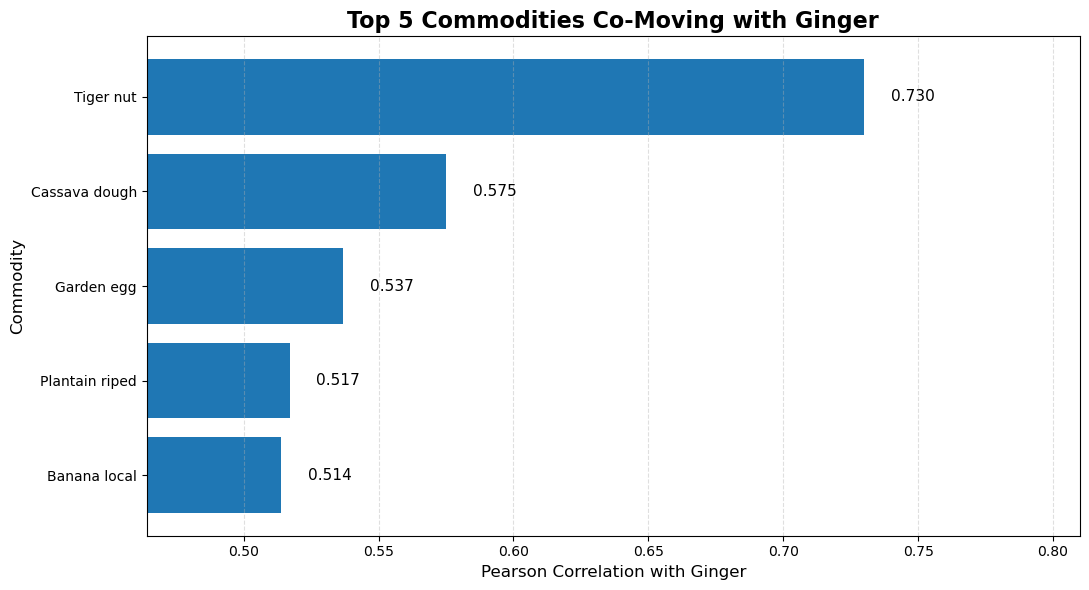

In [1]:
# ============================================
# TOP 5 COMMODITIES CO-MOVING WITH GINGER
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# 1. LOAD DATA
# --------------------------------------------

file_path = (r"C:\Users\T H I N K P A D\Downloads\Commodity prices _(Cleaned).csv")

df = pd.read_csv(file_path)

# --------------------------------------------
# 2. CLEAN DATA
# --------------------------------------------

# Dataset uses DD/MM/YYYY
df["Date"] = pd.to_datetime(
    df["Date"],
    dayfirst=True,
    errors="coerce"
)

df["Price"] = pd.to_numeric(
    df["Price"],
    errors="coerce"
)

df = df.dropna(
    subset=["Date", "Commodity", "Price"]
)

# --------------------------------------------
# 3. AVERAGE PRICE BY DATE AND COMMODITY
# --------------------------------------------

daily_prices = (
    df.groupby(
        ["Date", "Commodity"],
        as_index=False
    )["Price"]
    .mean()
)

# Convert to wide format
daily_prices = daily_prices.pivot(
    index="Date",
    columns="Commodity",
    values="Price"
)

# --------------------------------------------
# 4. CHECK THAT GINGER EXISTS
# --------------------------------------------

ginger_matches = [
    col for col in daily_prices.columns
    if "ginger" in str(col).lower()
]

print("Ginger columns found:")
print(ginger_matches)

if len(ginger_matches) == 0:
    raise ValueError(
        "Ginger was not found in the Commodity column."
    )

# Use the exact commodity name
ginger = ginger_matches[0]

print("\nUsing commodity:", ginger)

# --------------------------------------------
# 5. REMOVE COMMODITIES WITH TOO FEW
#    OBSERVATIONS
# --------------------------------------------

daily_prices = daily_prices.dropna(
    axis=1,
    thresh=10
)

# --------------------------------------------
# 6. CALCULATE CORRELATION WITH GINGER
# --------------------------------------------

ginger_correlation = (
    daily_prices
    .corr(method="pearson", min_periods=10)[ginger]
)

# Remove Ginger itself
ginger_correlation = ginger_correlation.drop(
    labels=[ginger],
    errors="ignore"
)

# Remove missing correlations
ginger_correlation = ginger_correlation.dropna()

# --------------------------------------------
# 7. SORT BY STRONGEST POSITIVE CORRELATION
# --------------------------------------------

top_5_ginger = (
    ginger_correlation
    .sort_values(ascending=False)
    .head(5)
)

# --------------------------------------------
# 8. DISPLAY RESULTS
# --------------------------------------------

print("\n" + "=" * 65)
print("TOP 5 COMMODITIES CO-MOVING WITH GINGER")
print("=" * 65)

results = pd.DataFrame({
    "Commodity": top_5_ginger.index,
    "Correlation with Ginger": top_5_ginger.values
})

results["Correlation with Ginger"] = (
    results["Correlation with Ginger"]
    .round(3)
)

print(results.to_string(index=False))

# --------------------------------------------
# 9. CREATE BAR CHART
# --------------------------------------------

plt.figure(figsize=(11, 6))

bars = plt.barh(
    results["Commodity"],
    results["Correlation with Ginger"]
)

# Highest correlation at the top
plt.gca().invert_yaxis()

# Add correlation values
for bar, value in zip(
    bars,
    results["Correlation with Ginger"]
):
    plt.text(
        value + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=11
    )

plt.xlabel(
    "Pearson Correlation with Ginger",
    fontsize=12
)

plt.ylabel(
    "Commodity",
    fontsize=12
)

plt.title(
    "Top 5 Commodities Co-Moving with Ginger",
    fontsize=16,
    fontweight="bold"
)

plt.xlim(
    max(0, results["Correlation with Ginger"].min() - 0.05),
    min(1, results["Correlation with Ginger"].max() + 0.08)
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()